# Notebook 13: Alternative Dataset Integration (COVID-19 Radiography Database)
# for Cross-Dataset Generalization Testing

## Objective
Download and prepare the COVID-19 Radiography Database as a held-out,
cross-dataset generalization test set. This dataset provides an explicit
"Viral Pneumonia" category, useful for testing how well a Kermany-trained
model generalizes to viral pneumonia cases from a different source/population
-- directly relevant since VIRUS was the weakest class across all models in
our earlier results.

## Folder structure (fixed, do not change)
G:\Research paper\Research paper\Pneumonia-MultiModel-XAI\data set\
    raw\        <- original downloaded dataset goes here
    processed\  <- cleaned, ImageFolder-ready binary dataset goes here

In [2]:
# ============================================================
# Cell 2: Imports and Configuration
# ============================================================
import shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm

PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")

DATA_ROOT = PROJECT_ROOT / "data set"
RAW_DIR = DATA_ROOT / "raw" / "COVID-19_Radiography_Dataset"
PROCESSED_DIR = DATA_ROOT / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 260

print("Cell 2 : Config Set")
print(f"Raw data dir       : {RAW_DIR}")
print(f"Processed data dir : {PROCESSED_DIR}")

Cell 2 : Config Set
Raw data dir       : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/raw/COVID-19_Radiography_Dataset
Processed data dir : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed


In [2]:
# ============================================================
# Cell 3: Dataset Objective & Label Mapping Rules
# ============================================================
"""
Objective:
Prepare the COVID-19 Radiography Database as an external cross-dataset 
evaluation set to test binary generalization (NORMAL vs PNEUMONIA).

Label Mapping Strategy:
- Normal           -> NORMAL
- Viral Pneumonia  -> PNEUMONIA
- Lung_Opacity     -> PNEUMONIA
- COVID-19         -> Excluded
"""

print("Cell 3 : Label Mapping Rules Defined")
print("NORMAL    <- Normal")
print("PNEUMONIA <- Viral Pneumonia + Lung_Opacity")

Cell 3 : Label Mapping Rules Defined
NORMAL    <- Normal
PNEUMONIA <- Viral Pneumonia + Lung_Opacity


In [3]:
# ============================================================
# Cell 4: Download Dataset via Kaggle API (Optional / Verification)
# ============================================================
import subprocess

dataset_slug = "tawsifurrahman/covid19-radiography-database"

if RAW_DIR.exists() and any(RAW_DIR.iterdir()):
    print(f"Dataset already exists at: {RAW_DIR}. Skipping download.")
else:
    print(f"Downloading {dataset_slug}...")
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "kaggle", "datasets", "download",
        "-d", dataset_slug,
        "-p", str(RAW_DIR),
        "--unzip"
    ], check=True)
    print("Download and extraction complete.")

Dataset already exists at: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/raw/COVID-19_Radiography_Dataset. Skipping download.


In [4]:
# ============================================================
# Cell 5: Inspect Downloaded Folder Structure
# ============================================================
for item in RAW_DIR.rglob("*"):
    if item.is_dir():
        print(item.relative_to(RAW_DIR))

Lung_Opacity
Normal
Viral Pneumonia
Lung_Opacity/images
Lung_Opacity/masks
Normal/images
Normal/masks
Viral Pneumonia/images
Viral Pneumonia/masks


In [5]:
# ============================================================
# Cell 6: Map Classes to Binary NORMAL / PNEUMONIA and Organize
# ============================================================
def resolve_source_folder(base_folder_name):
    """Resolves whether to use 'images' subfolder or root folder to prevent duplicates."""
    target_path = RAW_DIR / base_folder_name
    images_subfolder = target_path / "images"
    if images_subfolder.exists():
        return images_subfolder
    elif target_path.exists():
        return target_path
    return None

SOURCE_DIRS = {
    "NORMAL": [
        p for p in [resolve_source_folder("Normal"), resolve_source_folder("normal")] if p
    ],
    "PNEUMONIA": [
        p for p in [
            resolve_source_folder("Viral Pneumonia"),
            resolve_source_folder("viral"),
            resolve_source_folder("Lung_Opacity"),
            resolve_source_folder("lung_opacity")
        ] if p
    ]
}

for class_name in ["NORMAL", "PNEUMONIA"]:
    (PROCESSED_DIR / class_name).mkdir(parents=True, exist_ok=True)

def process_and_copy(src_folder, dest_folder, prefix):
    if not src_folder or not src_folder.exists():
        return 0
    
    count = 0
    valid_extensions = {".png", ".jpg", ".jpeg"}
    # Case-insensitive extension search using iterdir()
    images = [f for f in src_folder.iterdir() if f.suffix.lower() in valid_extensions]
    
    for img_path in tqdm(images, desc=f"Processing {prefix}"):
        try:
            with Image.open(img_path) as img:
                img_rgb = img.convert("RGB")
                img_resized = img_rgb.resize((IMAGE_SIZE, IMAGE_SIZE))
                out_name = f"{prefix}_{img_path.stem}.png"
                img_resized.save(dest_folder / out_name)
                count += 1
        except Exception:
            continue
    return count

normal_count = 0
for src in SOURCE_DIRS["NORMAL"]:
    normal_count += process_and_copy(src, PROCESSED_DIR / "NORMAL", "normal")

pneumonia_count = 0
for src in SOURCE_DIRS["PNEUMONIA"]:
    prefix_name = src.parent.name if src.name == "images" else src.name
    pneumonia_count += process_and_copy(
        src, PROCESSED_DIR / "PNEUMONIA", prefix_name.replace(" ", "_").lower()
    )

print(f"\nNORMAL images processed    : {normal_count}")
print(f"PNEUMONIA images processed : {pneumonia_count}")

# Explicit validation check to prevent silent failures
if normal_count == 0 or pneumonia_count == 0:
    raise ValueError(
        f"Dataset processing failed! Found NORMAL: {normal_count}, PNEUMONIA: {pneumonia_count}. "
        "Check source folder paths."
    )

Processing lung_opacity: 100%|██████████| 6012/6012 [02:16<00:00, 44.01it/s]


NORMAL images processed    : 20384
PNEUMONIA images processed : 13369


In [6]:
# ============================================================
# Cell 7: Verify Processed Dataset Summary
# ============================================================
print("=" * 70)
print("Cell 7 : Processed Dataset Summary")
print("-" * 70)

for class_name in ["NORMAL", "PNEUMONIA"]:
    count = len(list((PROCESSED_DIR / class_name).glob("*.png")))
    print(f"{class_name:<12} : {count} images")

print("=" * 70)
print(f"Saved to : {PROCESSED_DIR}")

Cell 7 : Processed Dataset Summary
----------------------------------------------------------------------
NORMAL       : 10192 images
PNEUMONIA    : 7357 images
Saved to : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed


In [3]:
# ============================================================
# Cell 8: Create PyTorch Dataset & DataLoader for Cross-Evaluation
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CrossEvaluationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Class mapping: NORMAL -> 0, PNEUMONIA -> 1
        self.class_to_idx = {"NORMAL": 0, "PNEUMONIA": 1}
        
        for class_name, idx in self.class_to_idx.items():
            class_dir = self.root_dir / class_name
            if class_dir.exists():
                for img_path in class_dir.glob("*.png"):
                    self.image_paths.append(img_path)
                    self.labels.append(idx)
                    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            
        if self.transform:
            img = self.transform(img)
            
        return img, label, str(img_path)

# ImageNet Standard Normalization (Consistent with Notebook 02 & PneumoXNet Pipeline)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = CrossEvaluationDataset(PROCESSED_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print("Cell 8 : DataLoader Configured")
print(f"Total Test Samples : {len(test_dataset)}")
print(f"Class Mapping      : {test_dataset.class_to_idx}")

Cell 8 : DataLoader Configured
Total Test Samples : 17549
Class Mapping      : {'NORMAL': 0, 'PNEUMONIA': 1}


Cell 9 : Batch Validation Success
Batch Image Tensor Shape : torch.Size([32, 3, 260, 260])
Batch Label Tensor Shape : torch.Size([32])


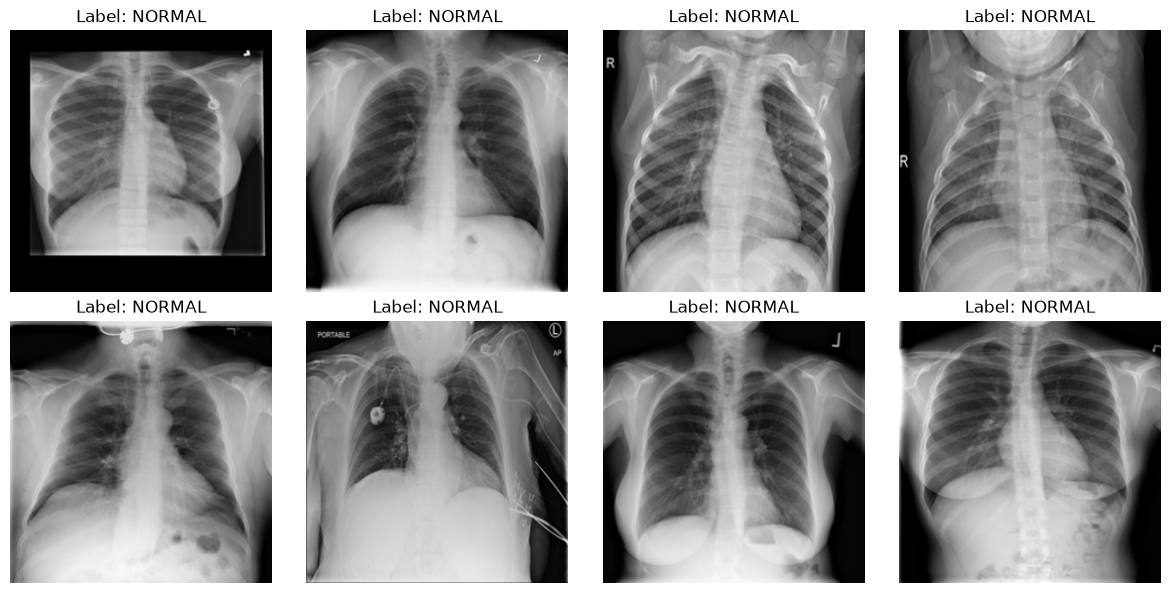

In [5]:
# ============================================================
# Cell 9: Validate Data Batches & Class Distribution
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

images, labels, paths = next(iter(test_loader))

print("Cell 9 : Batch Validation Success")
print(f"Batch Image Tensor Shape : {images.shape}")
print(f"Batch Label Tensor Shape : {labels.shape}")


# Un-normalize for visualization
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = unnormalize(images[i]).permute(1, 2, 0).numpy()
        # np.clip handles array element clipping without ambiguous boolean evaluation
        img = np.clip(img, 0.0, 1.0)

        label_str = idx_to_class[labels[i].item()]
        ax.imshow(img)
        ax.set_title(f"Label: {label_str}")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Cell 10: Load Trained PneumoXNet Model & Run Inference
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import timm
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path Configuration Verification
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")
PROCESSED_DIR = PROJECT_ROOT / "data set" / "processed"
MODEL_PATH = PROJECT_ROOT / "models" / "PneumoXNet_best.pth"

# 1. Dataset & DataLoader Fallback Initialization
if 'test_loader' not in globals():
    class CrossEvaluationDataset(Dataset):
        def __init__(self, root_dir, transform=None):
            self.root_dir = Path(root_dir)
            self.transform = transform
            self.image_paths = []
            self.labels = []
            self.class_to_idx = {"NORMAL": 0, "PNEUMONIA": 1}
            
            for class_name, idx in self.class_to_idx.items():
                class_dir = self.root_dir / class_name
                if class_dir.exists():
                    for img_path in class_dir.glob("*.png"):
                        self.image_paths.append(img_path)
                        self.labels.append(idx)
                        
        def __len__(self):
            return len(self.image_paths)
        
        def __getitem__(self, idx):
            img_path = self.image_paths[idx]
            label = self.labels[idx]
            with Image.open(img_path) as img:
                img = img.convert("RGB")
            if self.transform:
                img = self.transform(img)
            return img, label, str(img_path)

    test_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_dataset = CrossEvaluationDataset(PROCESSED_DIR, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# 2. PneumoXNet Architecture Definition
class PneumoXNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super(PneumoXNet, self).__init__()
        self.backbone = timm.create_model("tf_efficientnet_b2.ns_jft_in1k", pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

# 3. Model Weight Loading
model = PneumoXNet(num_classes=2, pretrained=False)
checkpoint = torch.load(MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict):
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint
    
    cleaned_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(cleaned_state_dict, strict=False)
else:
    model = checkpoint

model.to(device)
model.eval()

# 4. Inference Execution
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels, _ in tqdm(test_loader, desc="Evaluating PneumoXNet on Cross-Dataset"):
        images = images.to(device)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Cell 10 : Cross-Dataset Inference Completed Successfully")

Evaluating PneumoXNet on Cross-Dataset: 100%|██████████| 549/549 [01:03<00:00,  8.65it/s]

Cell 10 : Cross-Dataset Inference Completed Successfully


PneumoXNet - Cross-Dataset Generalization Performance
              precision    recall  f1-score   support

      NORMAL     0.0000    0.0000    0.0000     10192
   PNEUMONIA     0.4192    1.0000    0.5908      7357

    accuracy                         0.4192     17549
   macro avg     0.2096    0.5000    0.2954     17549
weighted avg     0.1758    0.4192    0.2477     17549

ROC-AUC Score : 0.5405


/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaimul/pytorch-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

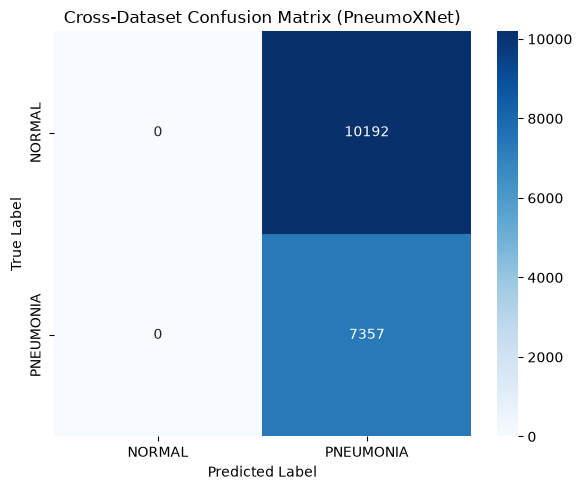

In [5]:
# ============================================================
# Cell 11: Cross-Dataset Evaluation Metrics & Confusion Matrix
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ensure variables exist
if 'all_labels' not in globals() or 'all_preds' not in globals():
    raise NameError("Run Cell 10 first to compute all_labels and all_preds!")

# Calculate Metrics
cm = confusion_matrix(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("=" * 70)
print("PneumoXNet - Cross-Dataset Generalization Performance")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"], digits=4))
print(f"ROC-AUC Score : {auc:.4f}")
print("=" * 70)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title("Cross-Dataset Confusion Matrix (PneumoXNet)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

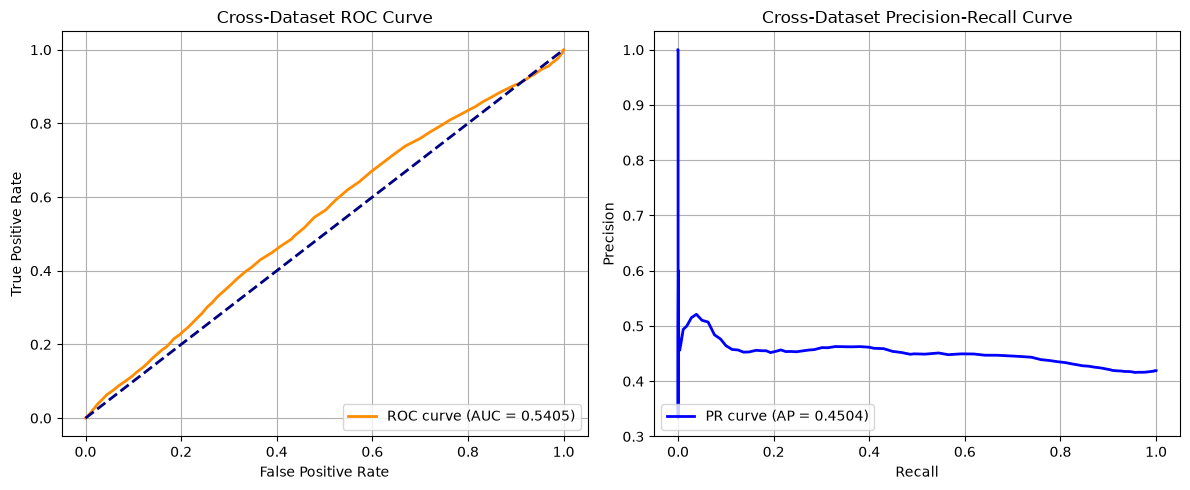

Cell 12 : ROC & PR Curves Generated


In [6]:
# ============================================================
# Cell 12: Plot ROC Curve & Precision-Recall Curve
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# Compute ROC and PR Curves
fpr, tpr, _ = roc_curve(all_labels, all_probs)
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC Curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Cross-Dataset ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Plot Precision-Recall Curve
axes[1].plot(recall, precision, color="blue", lw=2, label=f"PR curve (AP = {ap_score:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Cross-Dataset Precision-Recall Curve")
axes[1].legend(loc="lower left")
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Cell 12 : ROC & PR Curves Generated")